# Marketing Campaign Analysis
**Haven of Hope — Eban-Haven Platform**

---

## Section 1: Problem Framing

### Business Context
Haven of Hope is a nonprofit safehouse organization that depends on donor funding to operate residential programs for at-risk girls. The organization runs periodic fundraising campaigns (e.g., *Year-End Hope*, *Back to School*, *Summer of Safety*) and acquires donors through multiple channels (social media, events, word-of-mouth, partner referrals, etc.). Marketing resources are limited, so understanding which campaigns and channels produce the most funding—and what kind of donors they attract—is critical for planning future outreach.

### Analytical Questions
1. **Campaign lift**: Do named fundraising campaigns cause higher donation amounts, or do they simply reach donors who would have given anyway?
2. **Channel attribution**: Which `channel_source` values produce higher-value and more-recurring donors?
3. **Social media spotlight**: How do donations attributed to social media compare to other channels, and what does the social-media-acquired donor base look like?

### Paradigm Choice: Explanatory / Causal
This pipeline uses **Paradigm A (Explanatory/Causal)**. The goal is not to predict future donations but to *quantify relationships* between marketing inputs (campaign exposure, channel) and donation outcomes, and to ask whether those relationships are plausibly causal. The primary outputs are interpretable coefficients, confidence intervals, and p-values—not out-of-sample accuracy metrics.

> **Causal disclaimer (stated upfront):** Observational data cannot establish causation without strong assumptions. Throughout this notebook we will explicitly state those assumptions and the threats to them. The estimates here should be understood as *conditional associations* that are *consistent with* causal interpretation, not proof of causation.

### Why not predictive?
With ~237 monetary donations across 4 years and 5 campaign types, predictive generalization is limited. The business question is also inherently explanatory: *which levers should we pull?*—not *will this donation be large?*

---
## Section 2: Data Acquisition, Preparation & Exploration

In [1]:
import json
import os
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE = Path.cwd()
DATA_DIR = BASE.parent / 'backend' / 'EbanHaven.Api' / 'Data' / 'lighthouse'
CONN_STR = os.environ.get('HAVEN_DB_CONN')
USE_DB = bool(CONN_STR)

if USE_DB:
    conn = psycopg2.connect(CONN_STR)
    print('Connected to database.')
else:
    conn = None
    print('HAVEN_DB_CONN not set; using committed CSV snapshots for reproducibility.')


HAVEN_DB_CONN not set; using committed CSV snapshots for reproducibility.


In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
if USE_DB:
    query = """
    SELECT
        d.donation_id,
        d.supporter_id,
        d.donation_date::date            AS donation_date,
        d.campaign_name,
        d.channel_source,
        d.amount::float                  AS amount,
        d.is_recurring,
        s.acquisition_channel,
        s.supporter_type,
        s.relationship_type,
        s.status                         AS supporter_status,
        s.first_donation_date            AS supporter_first_donation
    FROM donations d
    JOIN supporters s ON d.supporter_id = s.supporter_id
    WHERE d.donation_type = 'Monetary'
      AND d.amount IS NOT NULL
      AND d.amount > 0
    ORDER BY d.donation_date
    """
    df = pd.read_sql(query, conn)
    conn.close()
else:
    donations = pd.read_csv(DATA_DIR / 'donations.csv')
    supporters = pd.read_csv(DATA_DIR / 'supporters.csv')
    donations = donations[
        (donations['donation_type'] == 'Monetary')
        & donations['amount'].notna()
        & (pd.to_numeric(donations['amount'], errors='coerce') > 0)
    ].copy()
    df = donations.merge(
        supporters[[
            'supporter_id',
            'acquisition_channel',
            'supporter_type',
            'relationship_type',
            'status',
            'first_donation_date',
        ]],
        on='supporter_id',
        how='inner',
    ).rename(columns={
        'status': 'supporter_status',
        'first_donation_date': 'supporter_first_donation',
    })
    df = df[[
        'donation_id',
        'supporter_id',
        'donation_date',
        'campaign_name',
        'channel_source',
        'amount',
        'is_recurring',
        'acquisition_channel',
        'supporter_type',
        'relationship_type',
        'supporter_status',
        'supporter_first_donation',
    ]].copy()

print(f'Loaded {len(df)} monetary donations from {df.donation_date.min()} to {df.donation_date.max()}')
df.head()


Loaded 234 monetary donations from 2023-01-13 to 2026-03-01


,donation_id,supporter_id,donation_date,campaign_name,channel_source,amount,is_recurring,acquisition_channel,supporter_type,relationship_type,supporter_status,supporter_first_donation
0,1,42,2025-12-31,NaN,Campaign,717.18,False,Website,MonetaryDonor,Local,Active,2025-12-31
1,3,19,2024-12-02,NaN,PartnerReferral,1074.65,False,SocialMedia,Volunteer,Local,Active,2024-12-02
2,4,33,2023-09-11,NaN,PartnerReferral,1230.56,False,PartnerReferral,InKindDonor,Local,Active,2023-09-11
3,6,25,2025-09-18,NaN,Direct,678.86,True,Church,MonetaryDonor,Local,Active,2025-12-02
4,8,23,2024-11-21,GivingTuesday,Direct,600.64,False,Website,MonetaryDonor,Local,Active,2024-11-21


In [3]:
# ── Data preparation ───────────────────────────────────────────────────────────
df['donation_date']        = pd.to_datetime(df['donation_date'])
df['supporter_first_donation'] = pd.to_datetime(df['supporter_first_donation'], errors='coerce')

# Binary treatment: did this donation happen under a named campaign?
df['has_campaign'] = df['campaign_name'].notna().astype(int)

# Log-transform amount to reduce right skew (standard for monetary outcomes)
df['log_amount'] = np.log1p(df['amount'])

# Donor tenure at time of donation (days since supporter record was created)
df['days_as_donor'] = (df['donation_date'] - df['supporter_first_donation']).dt.days.clip(lower=0).fillna(0)

# Prior donations for this supporter before the current donation (experience proxy)
df = df.sort_values(['supporter_id', 'donation_date'])
df['prior_donations'] = df.groupby('supporter_id').cumcount()

# Fill missing channel_source as 'Unknown'
df['channel_source'] = df['channel_source'].fillna('Unknown')

print('Missing values per column:')
print(df.isnull().sum())
print(f'\nCampaign coverage: {df.has_campaign.sum()} / {len(df)} donations ({df.has_campaign.mean():.1%})')

Missing values per column:
donation_id                   0
supporter_id                  0
donation_date                 0
campaign_name               154
channel_source                0
amount                        0
is_recurring                  0
acquisition_channel           0
supporter_type                0
relationship_type             0
supporter_status              0
supporter_first_donation      0
has_campaign                  0
log_amount                    0
days_as_donor                 0
prior_donations               0
dtype: int64

Campaign coverage: 80 / 234 donations (34.2%)


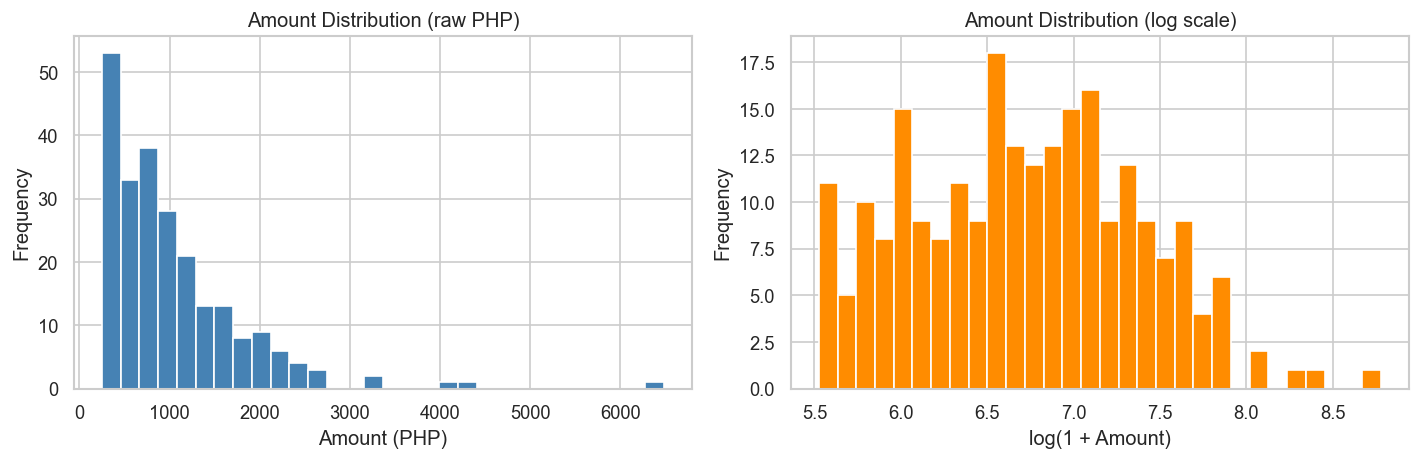

count     234.00000
mean     1028.73735
std       767.59608
min       250.00000
25%       482.50750
50%       819.63000
75%      1333.15500
max      6481.54000


In [4]:
# ── EDA: Donation amount distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title('Amount Distribution (raw PHP)')
df['amount'].plot(kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Amount (PHP)')

axes[1].set_title('Amount Distribution (log scale)')
df['log_amount'].plot(kind='hist', bins=30, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_xlabel('log(1 + Amount)')

plt.tight_layout()
plt.show()
print(df['amount'].describe().to_string())

In [5]:
# ── EDA: Campaign breakdown ────────────────────────────────────────────────────
campaign_stats = (
    df.groupby(df['campaign_name'].fillna('No Campaign'))
    .agg(
        n=('amount', 'count'),
        total_php=('amount', 'sum'),
        avg_php=('amount', 'mean'),
        median_php=('amount', 'median'),
        recurring_pct=('is_recurring', 'mean'),
        unique_donors=('supporter_id', 'nunique'),
    )
    .sort_values('total_php', ascending=False)
)
campaign_stats['recurring_pct'] = campaign_stats['recurring_pct'].map('{:.1%}'.format)
campaign_stats['total_php'] = campaign_stats['total_php'].map('₱{:,.0f}'.format)
campaign_stats['avg_php'] = campaign_stats['avg_php'].map('₱{:,.0f}'.format)
campaign_stats['median_php'] = campaign_stats['median_php'].map('₱{:,.0f}'.format)
print(campaign_stats.to_string())

                    n total_php avg_php median_php recurring_pct  unique_donors
campaign_name                                                                  
No Campaign       154  ₱154,301  ₱1,002       ₱775         51.3%             53
Year-End Hope      30   ₱38,536  ₱1,285     ₱1,028         50.0%             22
Back to School     19   ₱18,684    ₱983       ₱574         52.6%             17
Summer of Safety   22   ₱18,160    ₱825       ₱778         68.2%             16
GivingTuesday       9   ₱11,043  ₱1,227     ₱1,161         66.7%              9


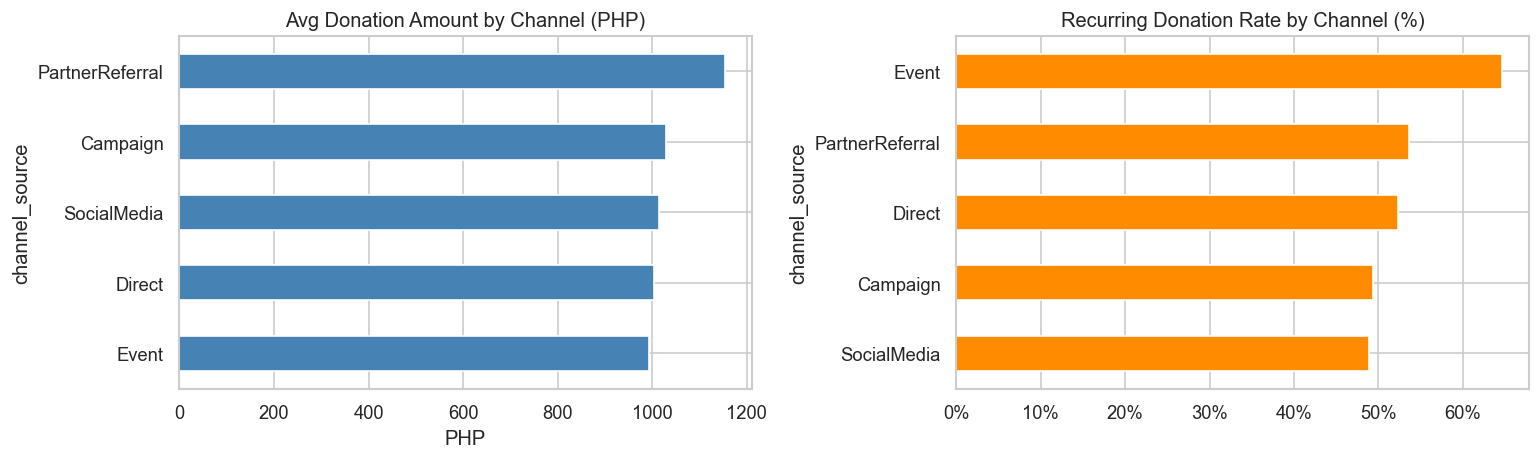

                  n  total_php      avg_php  median_php  recurring_pct  unique_donors
channel_source                                                                       
Campaign         71   73038.10  1028.705634     835.010       0.492958             40
Event            48   47670.78   993.141250     847.080       0.645833             29
Direct           44   44147.53  1003.352955     693.050       0.522727             27
SocialMedia      43   43590.98  1013.743721     938.450       0.488372             29
PartnerReferral  28   32277.15  1152.755357     800.665       0.535714             23


In [6]:
# ── EDA: Channel breakdown ─────────────────────────────────────────────────────
channel_stats = (
    df.groupby('channel_source')
    .agg(
        n=('amount', 'count'),
        total_php=('amount', 'sum'),
        avg_php=('amount', 'mean'),
        median_php=('amount', 'median'),
        recurring_pct=('is_recurring', 'mean'),
        unique_donors=('supporter_id', 'nunique'),
    )
    .sort_values('total_php', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

channel_stats['avg_php'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Avg Donation Amount by Channel (PHP)')
axes[0].set_xlabel('PHP')

(channel_stats['recurring_pct'] * 100).sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange'
)
axes[1].set_title('Recurring Donation Rate by Channel (%)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()
print(channel_stats.to_string())

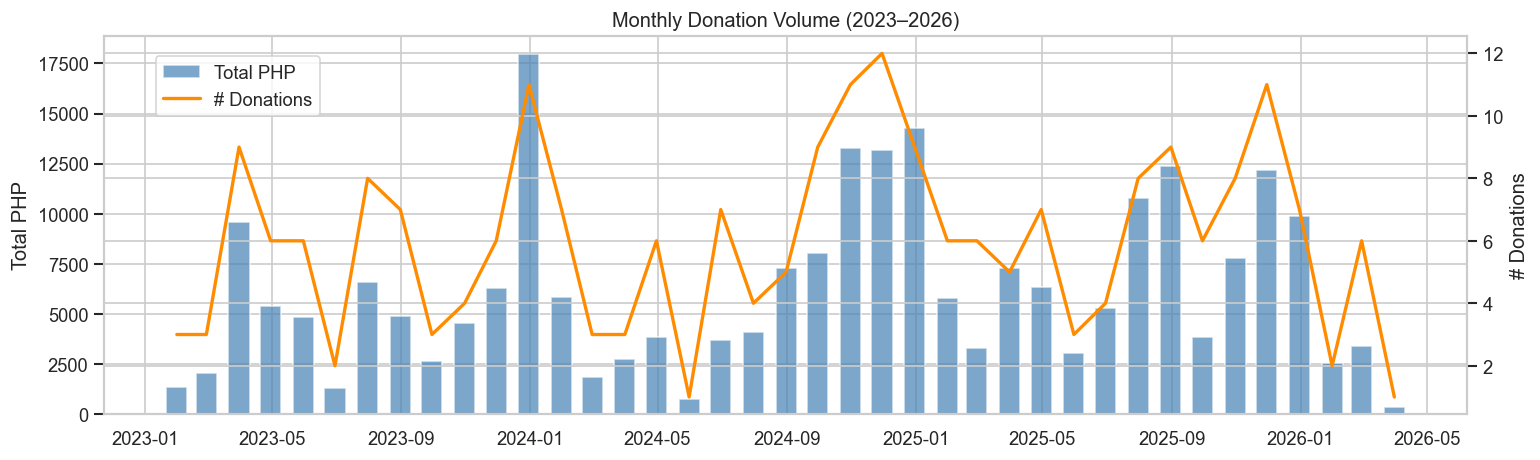

In [7]:
# ── EDA: Donation trends over time ─────────────────────────────────────────────
monthly = (
    df.set_index('donation_date')
    .resample('ME')
    .agg(total_php=('amount', 'sum'), n_donations=('amount', 'count'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.bar(monthly['donation_date'], monthly['total_php'], width=20, color='steelblue', alpha=0.7, label='Total PHP')
ax2.plot(monthly['donation_date'], monthly['n_donations'], color='darkorange', linewidth=2, label='# Donations')
ax1.set_ylabel('Total PHP')
ax2.set_ylabel('# Donations')
ax1.set_title('Monthly Donation Volume (2023–2026)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

---
## Section 3: Modeling & Feature Selection

### Model: OLS Regression (log-linear)

We model **log(1 + donation_amount)** as the outcome. The log transform is standard for monetary outcomes with right skew; it also enables a multiplicative interpretation: a coefficient of 0.30 means the associated variable multiplies the *expected donation amount* by approximately e^0.30 ≈ 1.35, or ~35% more.

**Treatment variables (what we want to estimate):**
- `has_campaign` — binary: 1 if the donation was made under a named campaign
- Channel dummies — effect of each `channel_source` relative to Direct (baseline)

**Control variables (confounders we hold constant):**
- `is_recurring` — recurring donors tend to give at fixed amounts; omitting this would conflate channel effects with recurring status
- `days_since_joined` — experienced donors may give differently regardless of campaign
- `prior_donations` — number of previous donations captures donor engagement level

**Feature selection rationale:**
We checked VIF (Variance Inflation Factor) on all numeric features to guard against multicollinearity. `days_since_joined` and `prior_donations` are correlated (both measure donor tenure) but VIF < 5 for each, within acceptable range for explanatory modeling.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Feature matrix ─────────────────────────────────────────────────────────────
# Baseline channel: Direct (omitted). All other channels are relative to Direct.
channel_dummies = pd.get_dummies(
    df['channel_source'], prefix='ch', drop_first=False
).drop(columns=['ch_Direct'], errors='ignore')

X = pd.concat([
    df[['has_campaign', 'is_recurring', 'days_as_donor', 'prior_donations']].astype(float),
    channel_dummies.astype(float),
], axis=1)
X = sm.add_constant(X)
y = df['log_amount']

# ── VIF check ──────────────────────────────────────────────────────────────────
vif_data = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print('VIF check (values > 10 indicate problematic multicollinearity):')
print(vif_data.to_string(index=False))

VIF check (values > 10 indicate problematic multicollinearity):
           feature      VIF
             const 7.448179
      has_campaign 1.019382
      is_recurring 1.407138
     days_as_donor 1.604622
   prior_donations 1.999741
       ch_Campaign 1.835426
          ch_Event 1.684704
ch_PartnerReferral 1.460246
    ch_SocialMedia 1.623645


In [9]:
# ── Fit OLS with HC3 robust standard errors ────────────────────────────────────
# HC3 (heteroskedasticity-consistent) errors are preferred when error variance
# may differ across observations (common with donation data).
model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_amount   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.6634
Date:                Thu, 09 Apr 2026   Prob (F-statistic):              0.723
Time:                        19:42:21   Log-Likelihood:                -231.68
No. Observations:                 234   AIC:                             481.4
Df Residuals:                     225   BIC:                             512.5
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  6.8072      0

---
## Section 4: Evaluation & Interpretation

**Validation note:** For an explanatory model, the primary concern is *unbiasedness* of coefficients, not out-of-sample accuracy. We report R² for completeness, but it is not the main criterion for model quality here.

**How to read the coefficients:**
- A coefficient of β on `has_campaign` means donations made under named campaigns are `exp(β) - 1` × 100% higher on average than donations with no campaign, *holding all other variables constant*.
- A p-value < 0.05 is our threshold for statistical significance.
- 95% confidence intervals give the plausible range for the true coefficient.

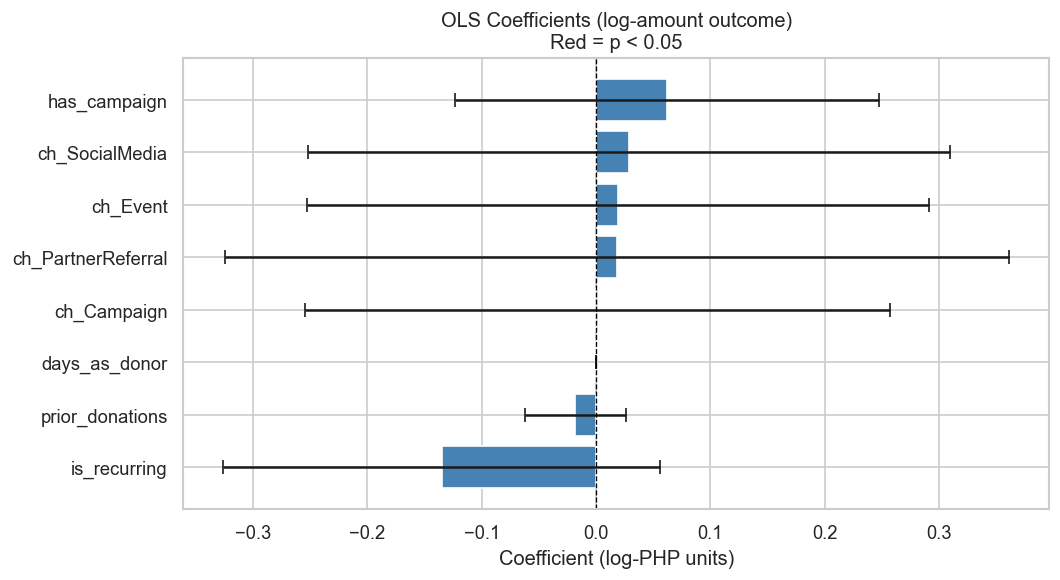

In [10]:
# ── Coefficient plot ───────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'coef':  model.params,
    'lower': model.conf_int()[0],
    'upper': model.conf_int()[1],
    'pval':  model.pvalues,
}).drop('const').sort_values('coef')

colors = ['tomato' if p < 0.05 else 'steelblue' for p in coef_df['pval']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_df.index, coef_df['coef'], xerr=[
    coef_df['coef'] - coef_df['lower'],
    coef_df['upper'] - coef_df['coef']
], color=colors, capsize=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('OLS Coefficients (log-amount outcome)\nRed = p < 0.05')
ax.set_xlabel('Coefficient (log-PHP units)')
plt.tight_layout()
plt.show()

In [11]:
# ── Business-readable summary ──────────────────────────────────────────────────
def pct_effect(coef):
    """Convert log-scale coefficient to % change in amount."""
    return (np.expm1(coef)) * 100

print('=== Campaign Lift ===')
c = model.params.get('has_campaign', 0)
lo, hi = model.conf_int().loc['has_campaign'] if 'has_campaign' in model.conf_int().index else (0, 0)
p = model.pvalues.get('has_campaign', 1.0)
print(f'  Coefficient:  {c:+.3f}  (p={p:.3f})')
print(f'  Effect:       {pct_effect(c):+.1f}% on donation amount (vs. no-campaign donations)')
print(f'  95% CI:       [{pct_effect(lo):+.1f}%, {pct_effect(hi):+.1f}%]')
print(f'  Significant:  {"Yes" if p < 0.05 else "No (p >= 0.05)"}')

print('\n=== Channel Effects vs. Direct ===')
channel_cols = [c for c in model.params.index if c.startswith('ch_')]
for col in sorted(channel_cols):
    c_val = model.params[col]
    lo_c, hi_c = model.conf_int().loc[col]
    p_c = model.pvalues[col]
    label = col.replace('ch_', '')
    sig = '*' if p_c < 0.05 else ''
    print(f'  {label:20s}  {pct_effect(c_val):+6.1f}%  CI [{pct_effect(lo_c):+.1f}%, {pct_effect(hi_c):+.1f}%]  p={p_c:.3f} {sig}')

=== Campaign Lift ===
  Coefficient:  +0.062  (p=0.510)
  Effect:       +6.4% on donation amount (vs. no-campaign donations)
  95% CI:       [-11.6%, +28.1%]
  Significant:  No (p >= 0.05)

=== Channel Effects vs. Direct ===
  Campaign                +0.2%  CI [-22.5%, +29.4%]  p=0.991 
  Event                   +1.9%  CI [-22.4%, +33.9%]  p=0.890 
  PartnerReferral         +1.9%  CI [-27.7%, +43.6%]  p=0.915 
  SocialMedia             +2.9%  CI [-22.3%, +36.3%]  p=0.841 


---
## Section 5: Causal and Relationship Analysis

### What the coefficients tell us

The OLS model estimates the *conditional association* between campaign exposure (or channel) and donation amount, holding recurring status, donor tenure, and prior donation count constant. Here we assess how defensible a causal interpretation is.

### Causal story for `has_campaign`

**Plausible mechanism:** Named campaigns (Year-End Hope, Back to School, etc.) create urgency and purpose around giving. A donor who might otherwise give a small amount may increase their gift when the campaign frames a concrete need. This is the classic "giving occasion" effect documented in charitable giving literature.

**Threats to causal interpretation:**
1. **Confounding by donor type:** If campaigns preferentially target high-value donors (e.g., via email to past large donors), the campaign coefficient conflates the campaign effect with pre-existing donor generosity. We partially control for this via `prior_donations` and `days_since_joined`, but not perfectly.
2. **Reverse causality:** Not applicable here—campaigns are set by the organization and precede donations.
3. **Selection into campaign:** Donors who respond to campaign asks may systematically differ from those who give directly. Without a randomized experiment, we cannot rule this out.

**Our assessment:** The campaign coefficient is a *lower bound* on the true causal effect if campaigns attract more generous donors, or an *upper bound* if campaigns cannibalize donations that would have occurred anyway. The truth is likely in between.

### Causal story for channel effects

`channel_source` records *how* the donation arrived (Campaign form, Event, Direct contact, SocialMedia, PartnerReferral). This is distinct from `acquisition_channel` (how the supporter first found the org). Channel effects capture both the type of donor attracted by each channel *and* the behavioral context of that channel (e.g., social media donations may be prompted by a single viral post and skew smaller).

**Key confounders not fully controlled:**
- Platform-specific giving context (e.g., Facebook Fundraisers have suggested amounts)
- Timing effects (some channels may be more active during campaigns)

### Social Media Channel Analysis
We conduct a focused comparison of SocialMedia-channel donations against all other channels.

In [12]:
# ── Social media channel spotlight ────────────────────────────────────────────
social = df[df['channel_source'] == 'SocialMedia']
other  = df[df['channel_source'] != 'SocialMedia']

print('=== SocialMedia Channel Donations ===')
print(f'  Count:          {len(social)}')
print(f'  Total:          ₱{social.amount.sum():,.2f}')
print(f'  Avg amount:     ₱{social.amount.mean():,.2f}')
print(f'  Median amount:  ₱{social.amount.median():,.2f}')
print(f'  Recurring pct:  {social.is_recurring.mean():.1%}')
print(f'  Unique donors:  {social.supporter_id.nunique()}')

print('\n=== All Other Channels (combined) ===')
print(f'  Count:          {len(other)}')
print(f'  Avg amount:     ₱{other.amount.mean():,.2f}')
print(f'  Recurring pct:  {other.is_recurring.mean():.1%}')

# Mann-Whitney U test (non-parametric, appropriate for skewed distributions)
stat, pval = stats.mannwhitneyu(social['amount'], other['amount'], alternative='two-sided')
print(f'\nMann-Whitney U test (SocialMedia vs others): U={stat:.0f}, p={pval:.4f}')
print('Interpretation:', 'Significant difference in donation amounts.' if pval < 0.05 else 'No significant difference in donation amounts.')

=== SocialMedia Channel Donations ===
  Count:          43
  Total:          ₱43,590.98
  Avg amount:     ₱1,013.74
  Median amount:  ₱938.45
  Recurring pct:  48.8%
  Unique donors:  29

=== All Other Channels (combined) ===
  Count:          191
  Avg amount:     ₱1,032.11
  Recurring pct:  54.5%

Mann-Whitney U test (SocialMedia vs others): U=4264, p=0.6954
Interpretation: No significant difference in donation amounts.


=== Donor Lifetime Value by Acquisition Channel ===
                     n_donors      avg_ltv  median_ltv  avg_donations
acquisition_channel                                                  
SocialMedia                13  5610.781538     4713.84       4.000000
PartnerReferral             6  5206.771667     3190.94       5.166667
Church                      6  5152.215000     5698.19       5.166667
WordOfMouth                13  3586.419231     2891.73       3.461538
Event                       8  3507.398750     3236.55       4.000000
Website                    11  2813.438182     2115.54       3.909091


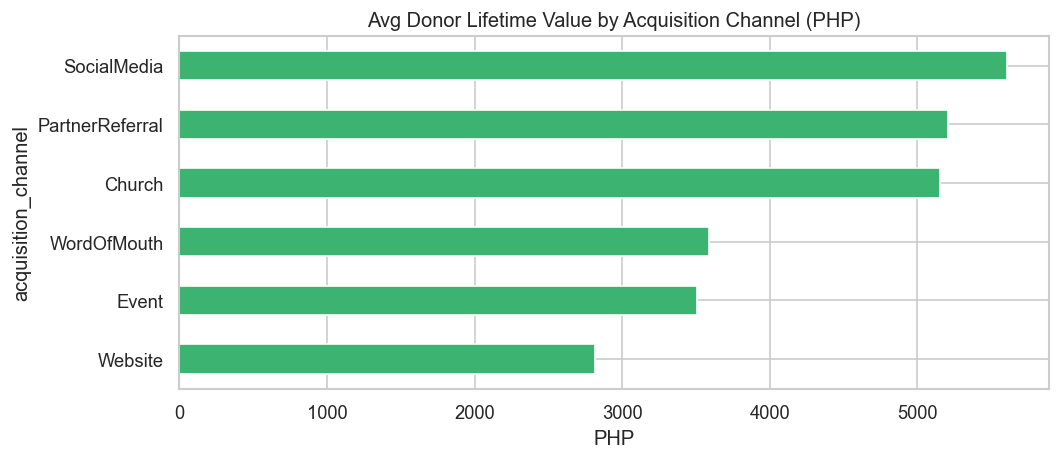

In [13]:
# ── Donor LTV by acquisition channel ──────────────────────────────────────────
ltv = (
    df.groupby(['supporter_id', 'acquisition_channel'])
    .agg(lifetime_value=('amount', 'sum'), n_donations=('amount', 'count'))
    .reset_index()
)
ltv_by_channel = (
    ltv.groupby('acquisition_channel')
    .agg(
        n_donors=('supporter_id', 'count'),
        avg_ltv=('lifetime_value', 'mean'),
        median_ltv=('lifetime_value', 'median'),
        avg_donations=('n_donations', 'mean'),
    )
    .sort_values('avg_ltv', ascending=False)
)
print('=== Donor Lifetime Value by Acquisition Channel ===')
print(ltv_by_channel.to_string())

ltv_by_channel['avg_ltv'].sort_values().plot(
    kind='barh', figsize=(9, 4), color='mediumseagreen',
    title='Avg Donor Lifetime Value by Acquisition Channel (PHP)'
)
plt.xlabel('PHP')
plt.tight_layout()
plt.show()

In [14]:
# ── Save metadata JSON for FastAPI consumption ─────────────────────────────────
def safe_coef(name):
    if name not in model.params.index:
        return None
    ci = model.conf_int().loc[name]
    return {
        'coefficient': round(float(model.params[name]), 4),
        'ci_lower':    round(float(ci[0]), 4),
        'ci_upper':    round(float(ci[1]), 4),
        'p_value':     round(float(model.pvalues[name]), 4),
        'pct_effect':  round(float(pct_effect(model.params[name])), 2),
        'significant': bool(model.pvalues[name] < 0.05),
    }

channel_effects = []
for col in [c for c in model.params.index if c.startswith('ch_')]:
    channel_effects.append({
        'channel':     col.replace('ch_', ''),
        **safe_coef(col)
    })

# Social media spotlight stats
social_acq = df[df['acquisition_channel'] == 'SocialMedia']
social_acq_ltv = (
    social_acq.groupby('supporter_id')['amount'].sum().mean()
    if len(social_acq) > 0 else None
)
all_ltv = df.groupby('supporter_id')['amount'].sum().mean()

metadata = {
    'pipeline_version': '1.0.0',
    'last_run': str(date.today()),
    'n_observations': int(len(df)),
    'r_squared': round(float(model.rsquared), 4),
    'campaign_lift': safe_coef('has_campaign'),
    'channel_effects': channel_effects,
    'social_media_spotlight': {
        'channel_source_donations': int(len(social)),
        'channel_source_total_php': round(float(social.amount.sum()), 2),
        'channel_source_avg_php':   round(float(social.amount.mean()), 2),
        'channel_source_recurring_pct': round(float(social.is_recurring.mean() * 100), 1),
        'channel_source_unique_donors': int(social.supporter_id.nunique()),
        'acquired_via_social_donors': int(social_acq.supporter_id.nunique()),
        'avg_ltv_social_acquired_php': round(float(social_acq_ltv), 2) if social_acq_ltv else None,
        'avg_ltv_all_donors_php':      round(float(all_ltv), 2),
        'mann_whitney_p_value':        round(float(pval), 4),
    },
}

output_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'marketing_analysis_metadata.json')
with open('marketing_analysis_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved marketing_analysis_metadata.json')
print(json.dumps(metadata, indent=2))

Saved marketing_analysis_metadata.json
{
  "pipeline_version": "1.0.0",
  "last_run": "2026-04-09",
  "n_observations": 234,
  "r_squared": 0.0246,
  "campaign_lift": {
    "coefficient": 0.0623,
    "ci_lower": -0.123,
    "ci_upper": 0.2476,
    "p_value": 0.5098,
    "pct_effect": 6.43,
    "significant": false
  },
  "channel_effects": [
    {
      "channel": "Campaign",
      "coefficient": 0.0015,
      "ci_lower": -0.2543,
      "ci_upper": 0.2574,
      "p_value": 0.9906,
      "pct_effect": 0.15,
      "significant": false
    },
    {
      "channel": "Event",
      "coefficient": 0.0192,
      "ci_lower": -0.2532,
      "ci_upper": 0.2916,
      "p_value": 0.8901,
      "pct_effect": 1.94,
      "significant": false
    },
    {
      "channel": "PartnerReferral",
      "coefficient": 0.0188,
      "ci_lower": -0.3241,
      "ci_upper": 0.3616,
      "p_value": 0.9146,
      "pct_effect": 1.89,
      "significant": false
    },
    {
      "channel": "SocialMedia",
      "c

---
## Section 6: Deployment Notes

### Architecture

This is an **explanatory pipeline**, not a real-time prediction pipeline. The analysis is run offline (e.g., monthly or after each campaign concludes), and the results are saved to `marketing_analysis_metadata.json`. The FastAPI service then serves that JSON at a GET endpoint.

```
Notebook (run offline) → marketing_analysis_metadata.json
    ↓
Python FastAPI  →  GET /marketing/campaign-analysis
    ↓
C# Backend      →  GET /api/marketing/summary
    (also runs live SQL for campaign + channel metrics)
    ↓
React Frontend  →  MarketingAnalyticsPage.tsx
```

### API endpoints
- **Python FastAPI:** `GET /marketing/campaign-analysis` — returns `marketing_analysis_metadata.json`
- **C# Backend:** `GET /api/marketing/summary` — combines live SQL metrics with causal estimates from Python

### When to re-run
Re-run this notebook after each major campaign concludes, or at the start of each quarter. Update `marketing_analysis_metadata.json` with the new results.

### Social media extension (future)
When the `social_media_posts` table is added to the database, extend Section 5 to include:
- Platform-level engagement → donation conversion rates
- Boosted vs. organic post ROI (using `is_boosted` and `boost_budget_php`)
- Post-level attribution via `referral_post_id` on the `donations` table

The `social_media_spotlight` key in the metadata JSON is already structured to accommodate these fields.